In [1]:
import sys

custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
if custom_module_path not in sys.path:
    sys.path.append(custom_module_path)

import instruments_jax as inst
import copy
import numpy as np
import json


# Step 1.a): Reading in csv - extracting single diffs and sums and configurations

In [2]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
wavelength_string = 760
obs_mode = "MBI"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)
print("Interleaved Values")
print("Length: ", len(interleaved_values))
print(interleaved_values)
print("Interleaved Stds")
print("Length: ", len(interleaved_stds))
print(interleaved_stds[0 : 10])
print("Configuration List")
print("Length: ", len(configuration_list))
print(configuration_list)

print(interleaved_stds[0])

Interleaved Values
Length:  320
[ 19866.    23740.5  -22265.5   22477.5   13337.5   22094.5  -15543.5
  21181.5   -1825.5   18824.      110.    19143.5  -13889.    16562.
  12902.    17644.5  -14556.5   16335.5   13596.5   17653.    -3387.5
  18323.5    2077.    18801.5   12197.    21847.   -14083.    21064.
  20120.5   24137.5  -22436.    22875.5   15688.5   22780.   -17572.
  21883.    20161.    24039.5  -22381.    22674.75  12334.5   22139.5
 -14414.    21295.5   -3194.    18743.5    1604.5   19184.5  -14446.
  16557.    13502.    17758.   -13795.5   16484.5   13102.    17583.5
  -1688.5   18628.      432.    18979.5   13512.5   22046.   -15333.
  21198.5    3221.5   20141.    -4612.    20053.    17069.5   23260.
 -18755.5   22276.    20285.    24323.   -22433.    22960.    11280.5
  22175.   -13264.    21412.    -4602.    18669.     3141.5   19245.
 -14799.5   16621.5   13886.    17961.   -12891.    16749.    12270.
  17794.     -109.    18976.    -1109.    19212.    -9865.5   1743

In [3]:
%%timeit

import copy


copy.deepcopy(interleaved_values)

2.83 µs ± 200 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


# Step 1.b) - Make plot of existing values as double diffs and sums

# Step 2: Creating a system Mueller matrix object

In [4]:
# Loading in previous fit from vampires_calibration
from pathlib import Path

fallback_filename = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/750-50_no_IMR_offset_fixed_EM_gain_iterate_on_any_improvement_ideal_start_table_phi_with_dichroic_best_fit_EM_gain_1.txt"
original_saved_fit_filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_no_IMR_offset_fixed_EM_gain_1_no_retardance_constraints_iterate_on_any_improvement_from_broadband_ideal_start_table_phi_with_dichroic_best_fit_old_fit_values.txt"
saved_fit_filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_no_IMR_offset_fixed_EM_gain_1_no_retardance_constraints_iterate_on_any_improvement_from_broadband_ideal_start_table_phi_FLC_delta_theta_pm10_with_dichroic_best_fit_old_fit_values.txt"

if Path(saved_fit_filename).exists():
    filename = saved_fit_filename
    print("Resuming from saved MBI scipy.minimize fit with FLC delta_theta +/- 10 deg: " + filename)
elif Path(original_saved_fit_filename).exists():
    filename = original_saved_fit_filename
    print("Starting from existing 760 MBI scipy.minimize fit: " + filename)
else:
    filename = fallback_filename
    print("Starting from closest broadband filter fit: " + filename)
with open(filename, "r") as f:
    past_fit = json.load(f)
past_fit.pop("wollaston", None)
past_fit.setdefault("image_rotator", {})
past_fit["image_rotator"].pop("delta_theta", None)

print(past_fit)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"] 
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"] 
offset_derot = 0
delta_opts = past_fit["optics"]["phi"]
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"] 
rot_FLC = past_fit["flc"]["delta_theta"]
dichroic_phi = past_fit.get("dichroic", {}).get("phi", 0)
dichroic_epsilon = past_fit.get("dichroic", {}).get("epsilon", 0)
dichroic_theta = past_fit.get("dichroic", {}).get("theta", 0)
em_gain = 1.0  # Fixed ideal EM gain

# Based on values in Six_And_Eleven_Parameter_Model_Best_MCMC_and_Scipy_Fits Google Sheets - having zeros for angles that're too large
# theta_pol = 0
# delta_HWP = 0.451  # Add your actual delta_HWP value
# offset_HWP = -2.642  # Add your actual offset_HWP value
# delta_derot = 0.32  # Add your actual delta_derot value
# offset_derot = 0  # Add your actual offset_derot value
# delta_opts = 0  # Add your actual delta_opts value
# epsilon_opts = 0  # Add your actual epsilon_opts value
# rot_opts = 0  # Add your actual rot_opts value
# delta_FLC = 0.5  # Add your actual delta_FLC value
# rot_FLC = 0  # Add your actual rot_FLC value
# em_gain = 1.2  # Add your actual em_gain value

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary
system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": dichroic_phi, "epsilon": dichroic_epsilon, "theta": dichroic_theta},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_derot, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        }
    }
}

Starting from existing 760 MBI scipy.minimize fit: /home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/760_no_IMR_offset_fixed_EM_gain_1_no_retardance_constraints_iterate_on_any_improvement_from_broadband_ideal_start_table_phi_with_dichroic_best_fit_old_fit_values.txt
{'dichroic': {'phi': -1.1447104924699028, 'epsilon': 0.04231883352999419, 'theta': 6.109835735508723}, 'flc': {'phi': 3.501713541084495, 'delta_theta': 4.999999984991414}, 'optics': {'phi': 1.767270636607728, 'epsilon': 1.0622706370803678e-12, 'theta': -4.777812739291021}, 'image_rotator': {'phi': 3.152932333349425}, 'hwp': {'phi': 2.916834658011647, 'delta_theta': -2.1036831646391683}, 'lp': {'theta': -5.0}}


In [5]:
# Converting system dictionary into system Mueller Matrix object

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())

[[ 0.48931992  0.48188605 -0.08496951  0.        ]
 [ 0.48931992  0.48188605 -0.08496951  0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]


# Step 4: Creating a dictionary of p0 starting guesses

{'dichroic': {'phi': -1.1447104924699028, 'epsilon': 0.04231883352999419, 'theta': 6.109835735508723}, 'flc': {'phi': 3.501713541084495, 'delta_theta': 4.999999984991414}, 'optics': {'phi': 1.767270636607728, 'epsilon': 1.0622706370803678e-12, 'theta': -4.777812739291021}, 'image_rotator': {'phi': 3.152932333349425}, 'hwp': {'phi': 2.916834658011647, 'delta_theta': -2.1036831646391683}, 'lp': {'theta': -5.0}}
logl value: 1384.5423496937728


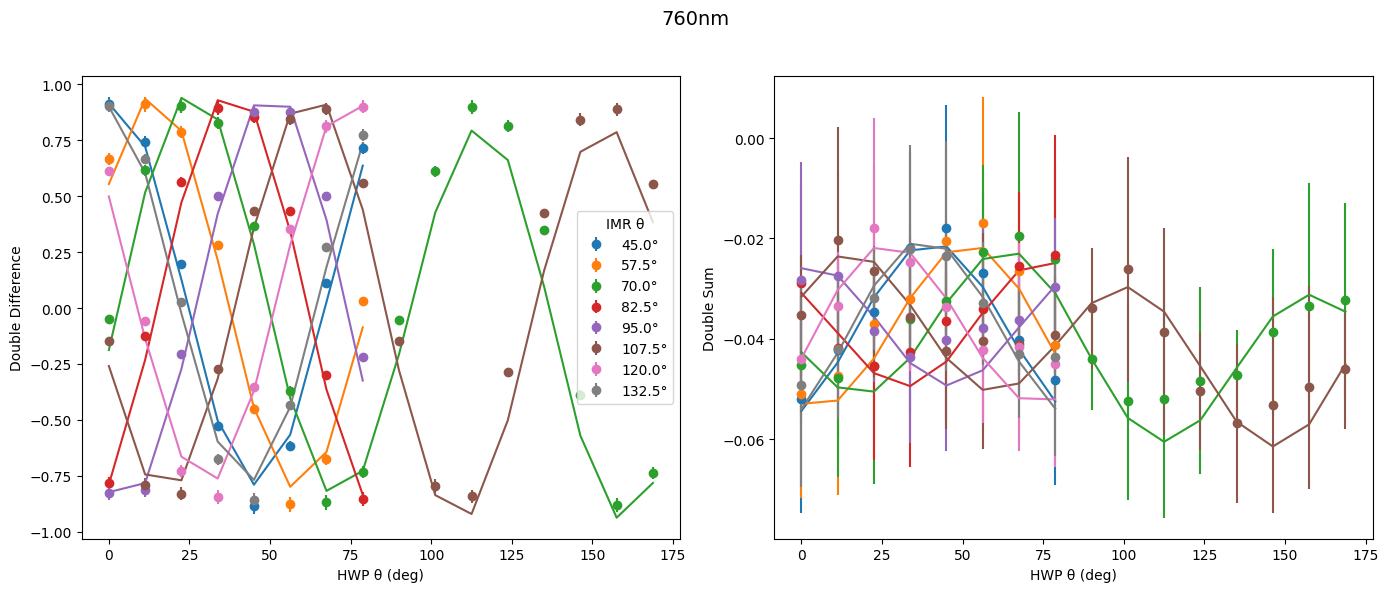

In [6]:
# Fitting all non-EM-gain parameters
p0 = copy.deepcopy(past_fit)
p0.pop("wollaston", None)

print(p0)

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 5: Running minimize_system_Mueller_matrix iteratively

Before p0: {'dichroic': {'phi': -1.1447104924699028, 'epsilon': 0.04231883352999419, 'theta': 6.109835735508723}, 'flc': {'phi': 3.501713541084495, 'delta_theta': 4.999999984991414}, 'optics': {'phi': 1.767270636607728, 'epsilon': 1.0622706370803678e-12, 'theta': -4.777812739291021}, 'image_rotator': {'phi': 3.152932333349425}, 'hwp': {'phi': 2.916834658011647, 'delta_theta': -2.1036831646391683}, 'lp': {'theta': -5.0}}
Iteration #: 1
logl_value: 1383.6716533671333
Best Fit Parameters: [-2.18183569e+00  4.22820397e-02  6.22635650e+00  3.49302700e+00
  8.80864180e+00  1.88015416e+00  3.72539861e-11 -3.19343627e+00
  3.15294439e+00  2.91748604e+00 -2.33696541e+00 -5.00000000e+00]
After p0: {'dichroic': {'phi': -2.18183568859292, 'epsilon': 0.042282039660278006, 'theta': 6.226356495728863}, 'flc': {'phi': 3.4930269978996646, 'delta_theta': 8.808641796878565}, 'optics': {'phi': 1.8801541564832123, 'epsilon': 3.7253986122564806e-11, 'theta': -3.193436274306407}, 'image_rotator': {'phi': 3.1

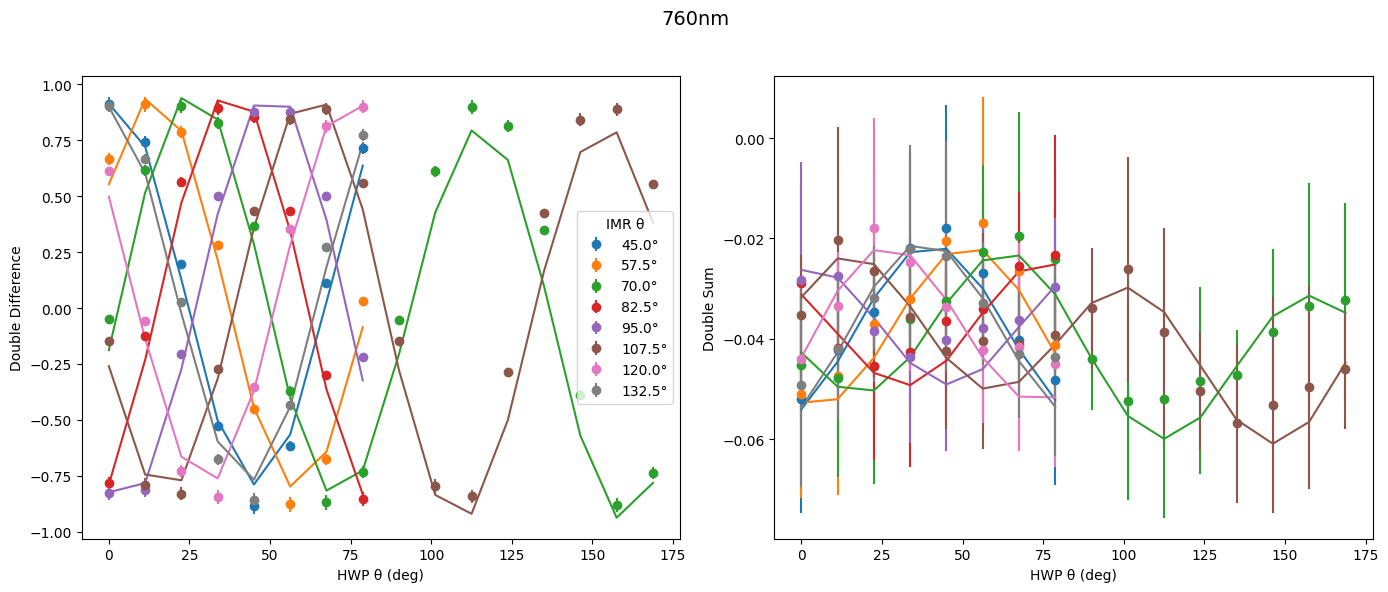

Before p0: {'dichroic': {'phi': -2.18183568859292, 'epsilon': 0.042282039660278006, 'theta': 6.226356495728863}, 'flc': {'phi': 3.4930269978996646, 'delta_theta': 8.808641796878565}, 'optics': {'phi': 1.8801541564832123, 'epsilon': 3.7253986122564806e-11, 'theta': -3.193436274306407}, 'image_rotator': {'phi': 3.152944394410712}, 'hwp': {'phi': 2.91748603855594, 'delta_theta': -2.3369654135070057}, 'lp': {'theta': -5.0}}
Iteration #: 2
logl_value: 1383.5810661743608
Best Fit Parameters: [-1.89364119e+00  4.22647521e-02  5.79448452e+00  3.49202651e+00
  8.56461268e+00  1.94644220e+00  1.87287699e-09 -1.55228610e+00
  3.15314555e+00  2.91756711e+00 -2.50695851e+00 -5.00000000e+00]
After p0: {'dichroic': {'phi': -1.8936411887127553, 'epsilon': 0.04226475207180938, 'theta': 5.794484517040338}, 'flc': {'phi': 3.4920265118914893, 'delta_theta': 8.564612684174339}, 'optics': {'phi': 1.9464422044799359, 'epsilon': 1.872876993187061e-09, 'theta': -1.5522861002134718}, 'image_rotator': {'phi': 3.

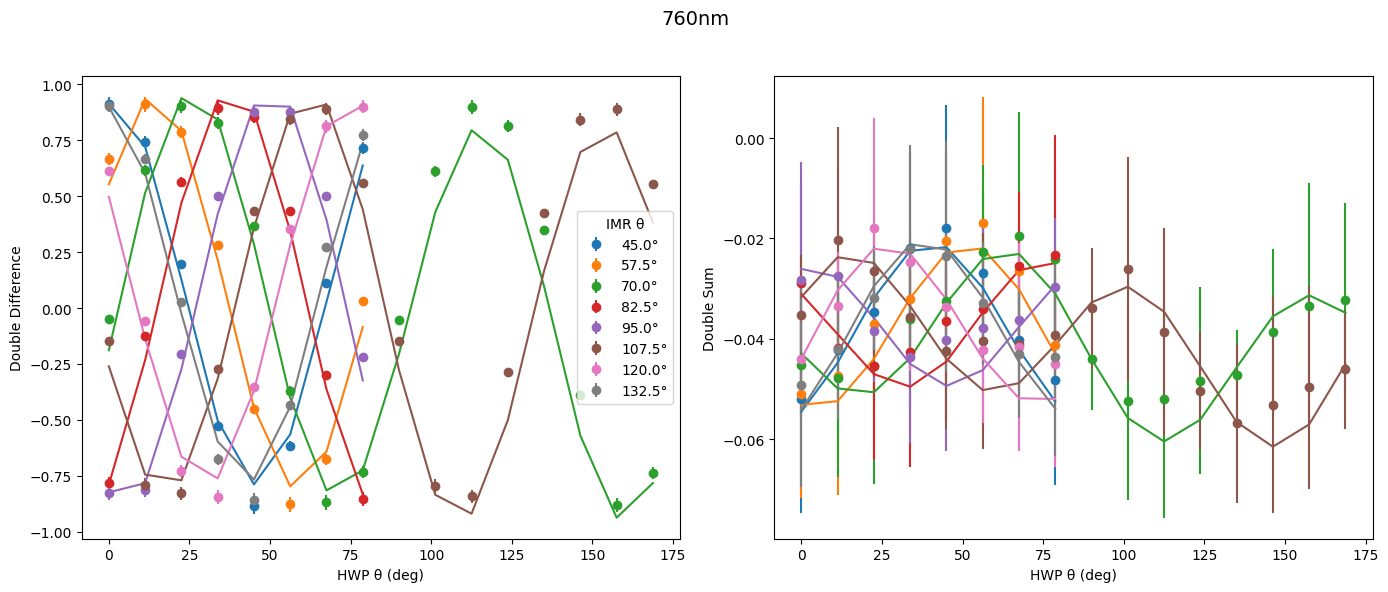

Before p0: {'dichroic': {'phi': -1.8936411887127553, 'epsilon': 0.04226475207180938, 'theta': 5.794484517040338}, 'flc': {'phi': 3.4920265118914893, 'delta_theta': 8.564612684174339}, 'optics': {'phi': 1.9464422044799359, 'epsilon': 1.872876993187061e-09, 'theta': -1.5522861002134718}, 'image_rotator': {'phi': 3.1531455451864403}, 'hwp': {'phi': 2.917567109611066, 'delta_theta': -2.5069585092310422}, 'lp': {'theta': -5.0}}
Iteration #: 3
logl_value: 1383.5097480975771
Best Fit Parameters: [-2.24447013e+00  4.25391710e-02  6.66090840e+00  3.49175037e+00
  9.99964522e+00  1.96375608e+00  4.56815116e-09 -1.76138557e+00
  3.15311987e+00  2.91762546e+00 -2.46726923e+00 -5.00000000e+00]
After p0: {'dichroic': {'phi': -2.244470126313818, 'epsilon': 0.04253917100492298, 'theta': 6.660908397811021}, 'flc': {'phi': 3.4917503735825606, 'delta_theta': 9.999645222137834}, 'optics': {'phi': 1.9637560750984666, 'epsilon': 4.568151158399898e-09, 'theta': -1.7613855705894061}, 'image_rotator': {'phi': 

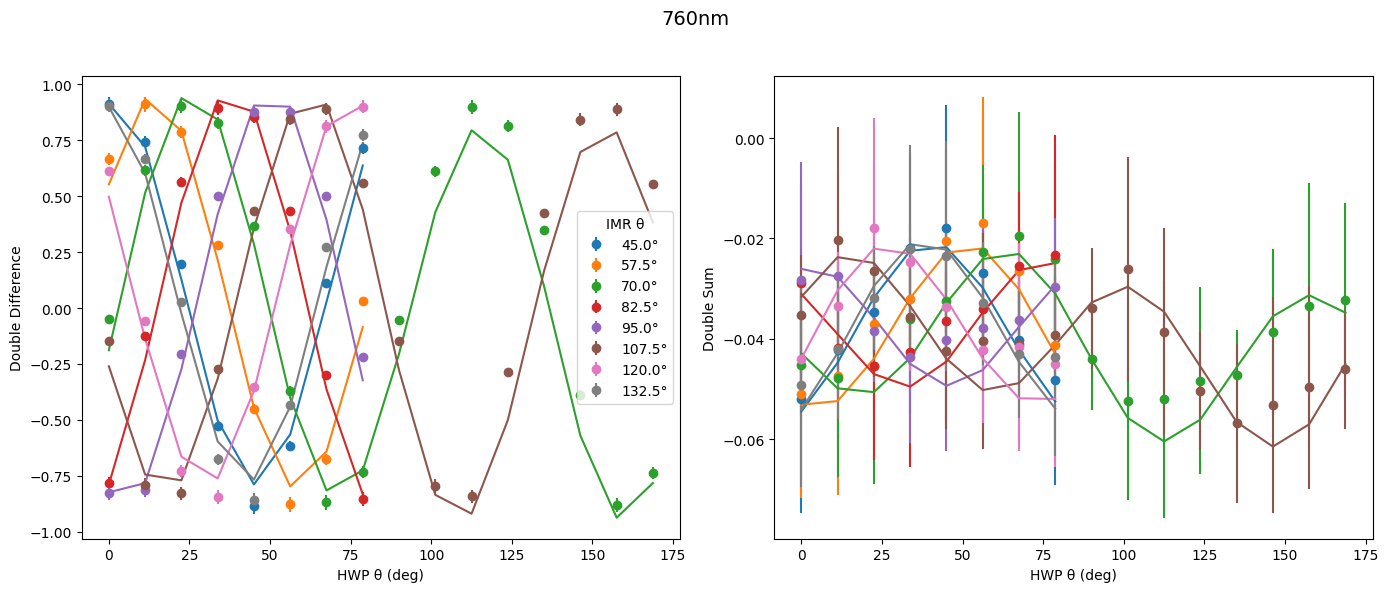

Before p0: {'dichroic': {'phi': -2.244470126313818, 'epsilon': 0.04253917100492298, 'theta': 6.660908397811021}, 'flc': {'phi': 3.4917503735825606, 'delta_theta': 9.999645222137834}, 'optics': {'phi': 1.9637560750984666, 'epsilon': 4.568151158399898e-09, 'theta': -1.7613855705894061}, 'image_rotator': {'phi': 3.153119872781585}, 'hwp': {'phi': 2.9176254555829084, 'delta_theta': -2.4672692328744503}, 'lp': {'theta': -5.0}}
Iteration #: 4
logl_value: 1383.5045277576885
Best Fit Parameters: [-2.19893733e+00  4.24990844e-02  6.52216059e+00  3.48993661e+00
  9.99991148e+00  1.98063714e+00  8.35334142e-12 -1.34446101e+00
  3.15313434e+00  2.91760900e+00 -2.49781886e+00 -5.00000000e+00]
After p0: {'dichroic': {'phi': -2.1989373273405786, 'epsilon': 0.04249908442528316, 'theta': 6.522160586723512}, 'flc': {'phi': 3.489936610630542, 'delta_theta': 9.999911478818458}, 'optics': {'phi': 1.9806371401853644, 'epsilon': 8.35334141917189e-12, 'theta': -1.3444610110894013}, 'image_rotator': {'phi': 3.

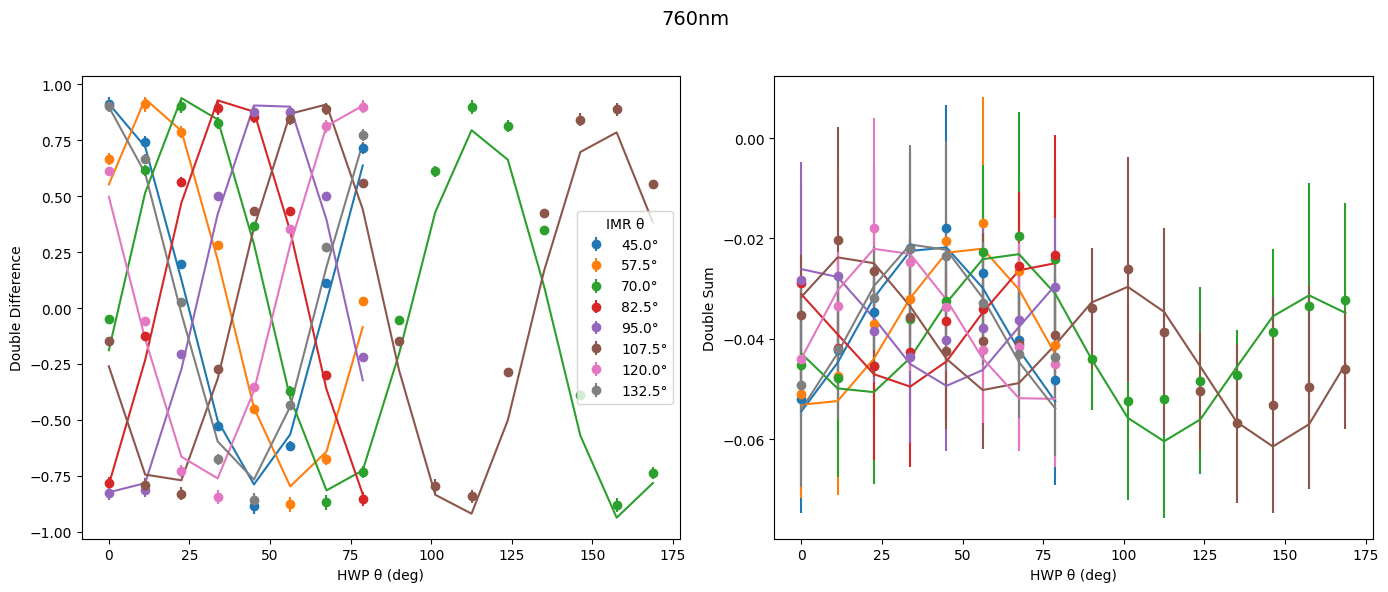

Before p0: {'dichroic': {'phi': -2.1989373273405786, 'epsilon': 0.04249908442528316, 'theta': 6.522160586723512}, 'flc': {'phi': 3.489936610630542, 'delta_theta': 9.999911478818458}, 'optics': {'phi': 1.9806371401853644, 'epsilon': 8.35334141917189e-12, 'theta': -1.3444610110894013}, 'image_rotator': {'phi': 3.1531343412481556}, 'hwp': {'phi': 2.917609001261198, 'delta_theta': -2.497818861912714}, 'lp': {'theta': -5.0}}
Iteration #: 5
logl_value: 1383.5045080023651
Best Fit Parameters: [-2.19816850e+00  4.24942092e-02  6.51970489e+00  3.48990594e+00
  9.99999975e+00  1.98063966e+00  8.93708133e-12 -1.33653429e+00
  3.15314038e+00  2.91758322e+00 -2.50091010e+00 -5.00000000e+00]
After p0: {'dichroic': {'phi': -2.1981685001732236, 'epsilon': 0.042494209160676734, 'theta': 6.5197048873875705}, 'flc': {'phi': 3.489905939294455, 'delta_theta': 9.999999745305345}, 'optics': {'phi': 1.9806396582118242, 'epsilon': 8.937081330952862e-12, 'theta': -1.3365342933180575}, 'image_rotator': {'phi': 3

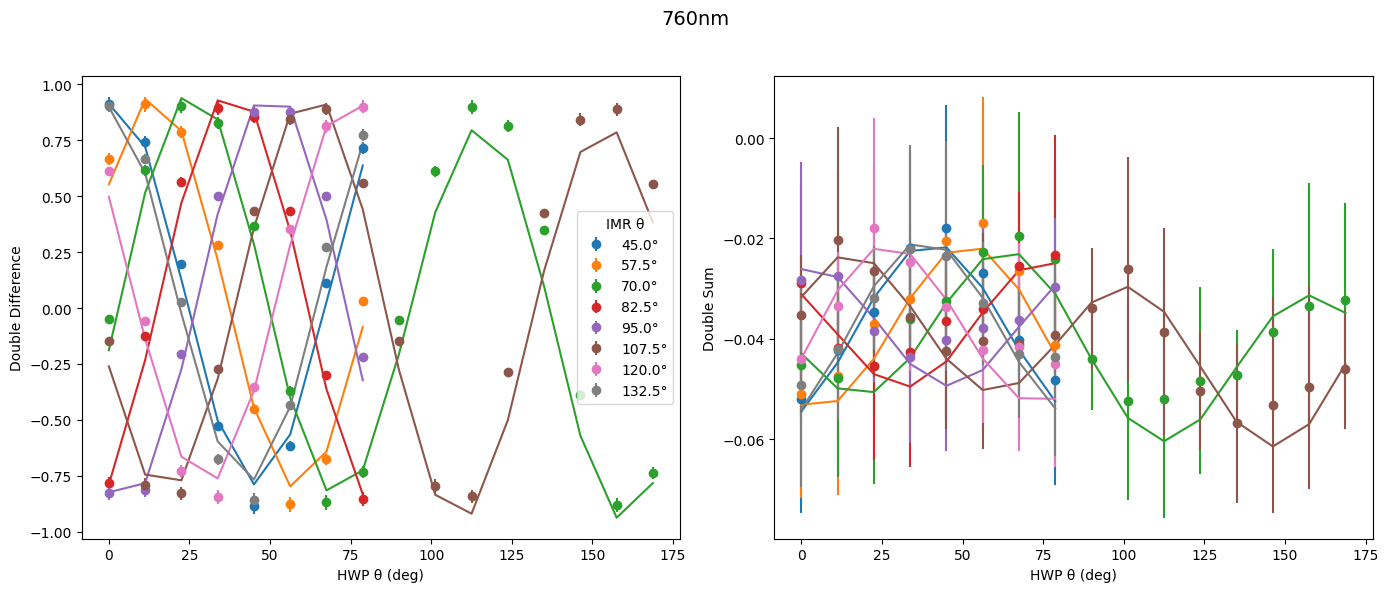

Before p0: {'dichroic': {'phi': -2.1981685001732236, 'epsilon': 0.042494209160676734, 'theta': 6.5197048873875705}, 'flc': {'phi': 3.489905939294455, 'delta_theta': 9.999999745305345}, 'optics': {'phi': 1.9806396582118242, 'epsilon': 8.937081330952862e-12, 'theta': -1.3365342933180575}, 'image_rotator': {'phi': 3.153140382670407}, 'hwp': {'phi': 2.9175832158293504, 'delta_theta': -2.500910097805505}, 'lp': {'theta': -5.0}}
Iteration #: 6
logl_value: 1383.5045080023651
Best Fit Parameters: [-2.19816850e+00  4.24942092e-02  6.51970489e+00  3.48990594e+00
  9.99999975e+00  1.98063966e+00  8.93708133e-12 -1.33653429e+00
  3.15314038e+00  2.91758322e+00 -2.50091010e+00 -5.00000000e+00]
Stopping: logl did not improve over the previous iteration.


In [7]:
# Unpolarized light for s_in as there is LP in the system already
s_in = np.array([1, 0, 0, 0])
bounds_dict = {
    "dichroic": {
        "phi": (-2 * np.pi, 2 * np.pi),
        "epsilon": (0, 1),
        "theta": (-90, 90)
    },
    "flc": {
        "phi": (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),
        "delta_theta": (-10, 10)
    },
    "optics": {
        "phi": (-2 * np.pi, 2 * np.pi),
        "epsilon": (0, 1),
        "theta": (-90, 90)
    },
    "image_rotator": {
        "phi": (delta_derot - abs(delta_derot) * 0.1, delta_derot + abs(delta_derot) * 0.1),
    },
    "hwp": {
        "phi": (delta_HWP - abs(delta_HWP) * 0.1, delta_HWP + abs(delta_HWP) * 0.1),
        "delta_theta": (-5, 5)
    },
    "lp": {
        "theta": (-5, 5)
    }
}

# Now flatten the bounds in the same order as p0_keywords
p0_values, p0_keywords = inst.parse_configuration(p0)
for (comp, param), val in zip(p0_keywords, p0_values):
    lower, upper = bounds_dict[comp][param]
    if not (lower <= val <= upper):
        print(f"{comp}.{param} = {val} is outside bounds {lower} to {upper}")
bounds = [bounds_dict[comp][param] for comp, param in p0_keywords]

# Counters for iterative fitting
iteration = 1
previous_logl_value = np.inf
new_logl_value = None
best_result = None

while True:
    print("Before p0: " + str(p0))
    result, new_logl_value = inst.minimize_system_mueller_matrix(p0, system_mm, 
        interleaved_values, interleaved_stds, configuration_list, s_in = s_in,
        process_dataset = inst.process_dataset, 
        process_errors = inst.process_errors, 
        process_model = inst.process_model, bounds = bounds)
    new_logl_value = float(new_logl_value)
    
    # Print statements
    print("Iteration #: " + str(iteration))
    print("logl_value: " + str(new_logl_value))
    print("Best Fit Parameters: " + str(result.x))

    if new_logl_value >= previous_logl_value:
        print("Stopping: logl did not improve over the previous iteration.")
        if best_result is not None:
            result = best_result
        break

    previous_logl_value = new_logl_value
    best_result = result

    # Updating p0 and saving the latest best fit before plotting.
    inst.update_p0(p0, result.x)
    print("After p0: " + str(p0))

    filename = saved_fit_filename
    with open(filename, 'w') as f:
        json.dump(p0, f, indent=4)
    print("Saved latest best fit to: " + filename)

    # Making a plot
    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(result.x, p0_keywords, updated_system_mm, configuration_list, 
    process_model = inst.process_model)

    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
        configuration_list, wavelength = wavelength_string)

    iteration += 1


# Step 6: Plot model with best fit

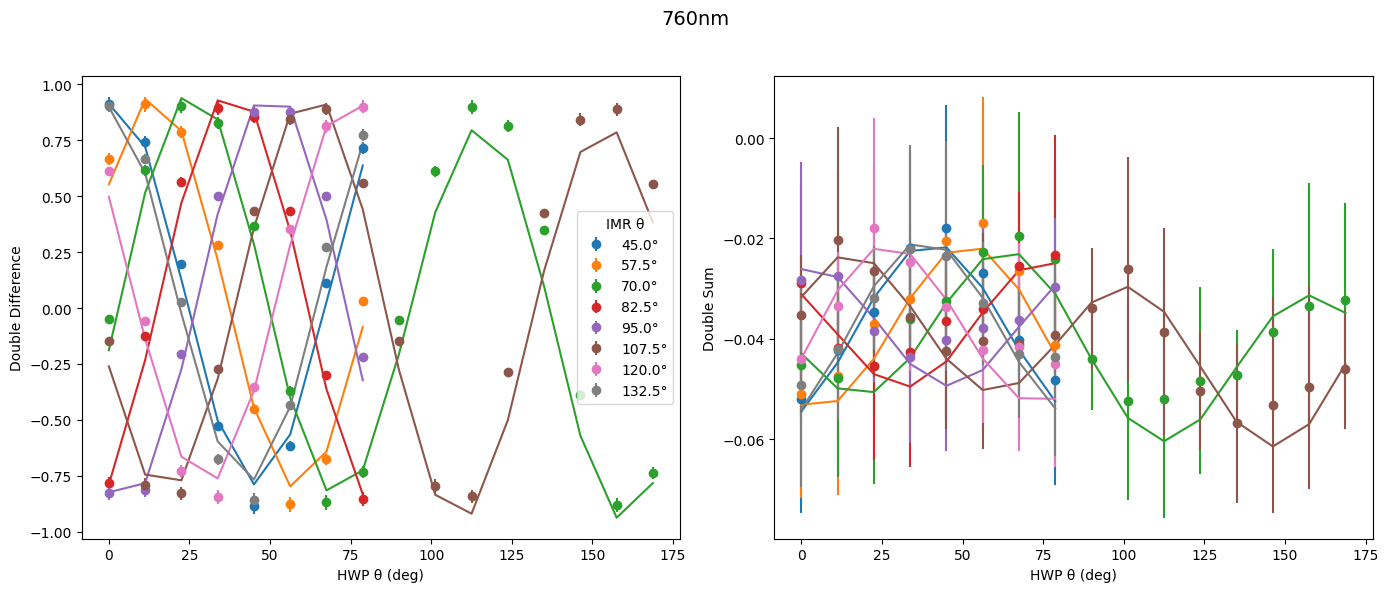

In [8]:
# Generate model with p0 keywords but scipy minimized results
# print(result.x)
# print(p0_keywords)

# Manually adjusting for a good fit
dichroic_phi = 0 # (waves)
dichroic_theta = 0 # (degrees)
# result.x = [2 * np.pi * dichroic_phi, dichroic_theta]

updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
model = inst.model(result.x, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)